In [1]:
!hostnamectl

 Static hostname: gpub001.delta.ncsa.illinois.edu
       Icon name: computer-server
         Chassis: server 🖳
      Machine ID: 81f2a3a0c8754cdb9ec6aae8833a8bc5
         Boot ID: 796f95973e364d82b8ba405c9b79da9e
Operating System: ]8;;https://www.redhat.com/Red Hat Enterprise Linux 9.4 (Plow)]8;;     
     CPE OS Name: cpe:/o:redhat:enterprise_linux:9::baseos
          Kernel: Linux 5.14.0-427.91.1.el9_4.x86_64
    Architecture: x86-64
Firmware Version: A48


In [2]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [3]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [4]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/All_Cell_Types.h5ad'
rna_path_filtered = '/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_rna_adata.h5ad'

In [5]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 292423 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation'
    var: 'features'
    uns: 'age_pop_colors'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

In [ ]:
# subset to samples of interest
#adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

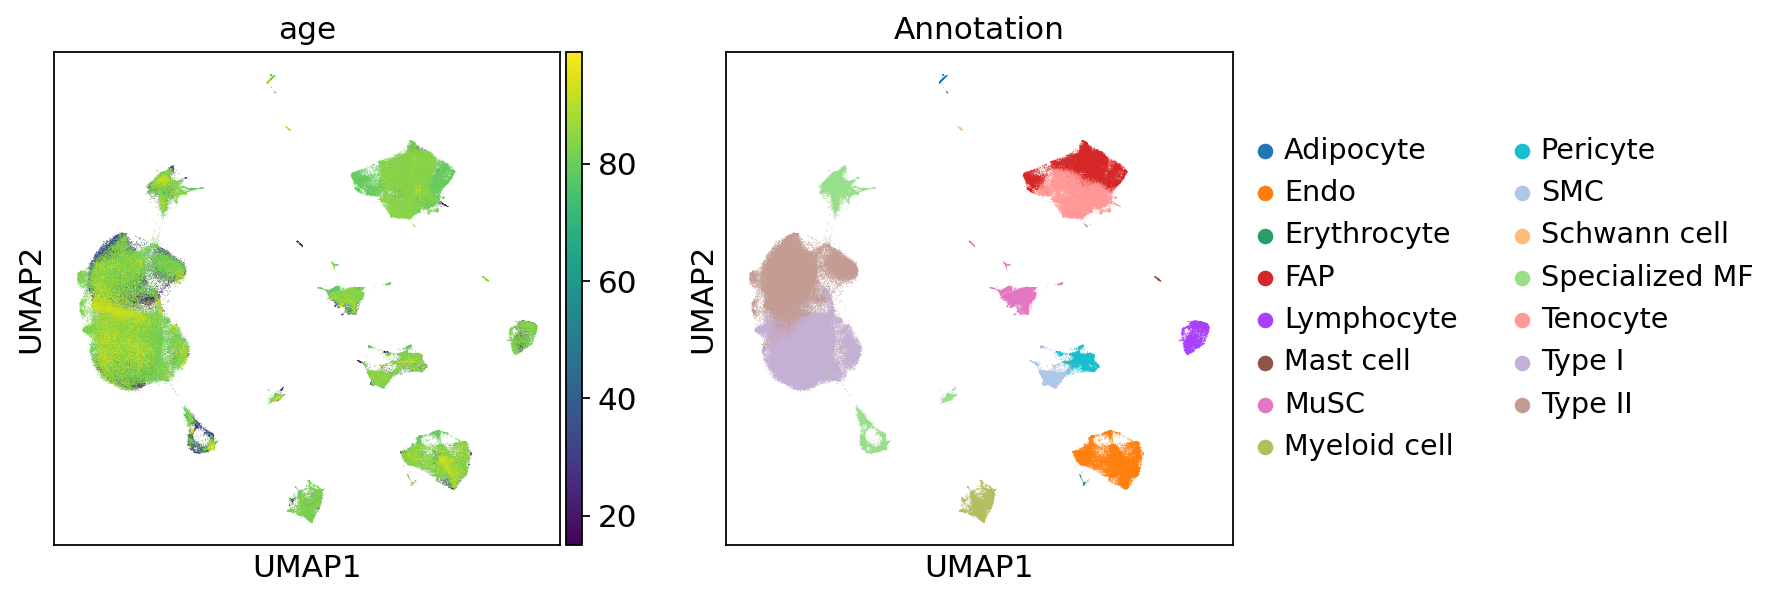

In [6]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])

In [7]:
rna_adata.obs['age'].value_counts()

age
80.0    70158
82.0    44201
84.0    42907
34.0    33403
79.0    27085
15.0    22273
45.0    11291
92.0     8595
18.0     8137
29.0     6465
89.0     6215
38.0     4150
85.0     2516
88.0     1416
77.0     1376
99.0     1366
17.0      869
Name: count, dtype: int64

In [8]:
rna_adata.obs['age_pop'].value_counts()

age_pop
old_pop      205835
young_pop     86588
Name: count, dtype: int64

In [9]:
n_cells_downsample = 20000
adatas = []

for age, idx in rna_adata.obs.groupby('age').groups.items():
    subset = rna_adata[idx].copy()
    if subset.shape[0] > n_cells_downsample:
        sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
    adatas.append(subset)

rna_adata = ad.concat(adatas)
del adatas

# Verify
print(rna_adata.obs['age'].value_counts())

age
15.0    20000
34.0    20000
79.0    20000
82.0    20000
80.0    20000
84.0    20000
45.0    11291
92.0     8595
18.0     8137
29.0     6465
89.0     6215
38.0     4150
85.0     2516
88.0     1416
77.0     1376
99.0     1366
17.0      869
Name: count, dtype: int64


In [10]:
# # save 
rna_adata.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad')

In [11]:
# make temporal info numeric
def adapt_time(x):
    if x["age_pop"] == "young_pop":
        return 1.5
    if x["age_pop"] == "old_pop":
        return 3.5
    raise ValueError

rna_adata.obs["age_pop"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

In [12]:
rna_adata.obs['age_pop'].value_counts()

age_pop
3.5    101484
1.5     70912
Name: count, dtype: int64

In [13]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="age_pop")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


In [ ]:
import networkx as nx

batch_column = "age_pop"
batch1, batch2 = 1.5, 3.5

indices = np.where(
    (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
)[0]

adata_subset = rna_adata[indices]
sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")

G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
assert nx.is_connected(G)

# if graph not connect check if there is a major disconnectivity due to batch effect in the latent space
# n_components = nx.number_connected_components(G)
# print(f"Number of connected components: {n_components}")
# # Check sizes of each component
# sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
# print(f"Component sizes: {sizes}")

Number of connected components: 1
Component sizes: [172396]


In [15]:
df = pd.DataFrame(
    index=adata_subset.obs_names,
    columns=adata_subset.obs_names,
    data=adata_subset.obsp["connectivities"].todense().astype("float"),
)

: 

: 

: 